# Variance, Covariance, Covariance Matrix, and PCA

This notebook introduces and explains the concepts of variance, covariance, covariance matrix, and Principal Component Analysis (PCA) with examples and visualizations.

## Variance
Variance measures how much a set of values is spread out around the mean.

The formula for variance of a random variable $X$ is:
$$
\text{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2]
$$

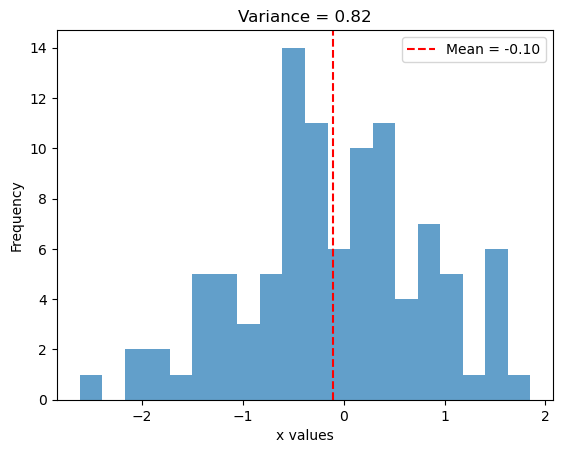

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.normal(0, 1, 100)
mean_x = np.mean(x)
variance_x = np.var(x)

plt.hist(x, bins=20, alpha=0.7)
plt.axvline(mean_x, color='r', linestyle='--', label=f'Mean = {mean_x:.2f}')
plt.title(f'Variance = {variance_x:.2f}')
plt.legend()
plt.xlabel('x values')
plt.ylabel('Frequency')
plt.show()

## Covariance
Covariance measures how much two random variables vary together. The formula is:
$$
\text{Cov}(X, Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])]
$$

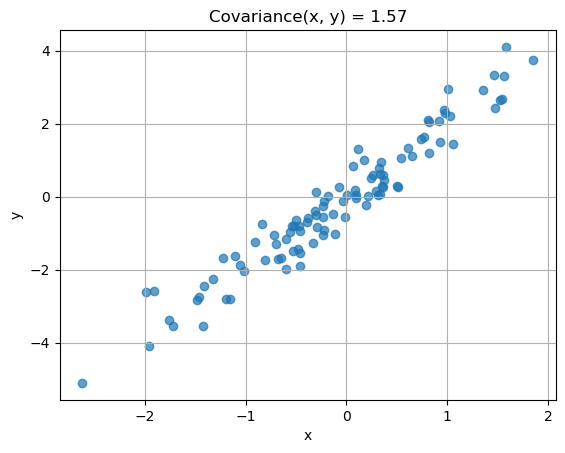

In [2]:
y = 2 * x + np.random.normal(0, 0.5, 100)
cov_xy = np.cov(x, y, bias=True)[0, 1]

plt.scatter(x, y, alpha=0.7)
plt.title(f'Covariance(x, y) = {cov_xy:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

## Covariance Matrix
A covariance matrix contains the covariances between all pairs of dimensions (variables) in the data.

Given a data matrix $X$ of shape $(n, d)$ (n samples, d features):
$$
\Sigma = \frac{1}{n} (X - \mu)^T (X - \mu)
$$

In [3]:
X = np.vstack((x, y)).T
cov_matrix = np.cov(X.T)
print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[0.82476989 1.59046269]
 [1.59046269 3.29014231]]


## Principal Component Analysis (PCA)
PCA is a technique to reduce the dimensionality of data by projecting it onto the directions of maximum variance (principal components).

Steps:
1. Center the data
2. Compute the covariance matrix
3. Compute eigenvectors and eigenvalues
4. Project data onto principal components

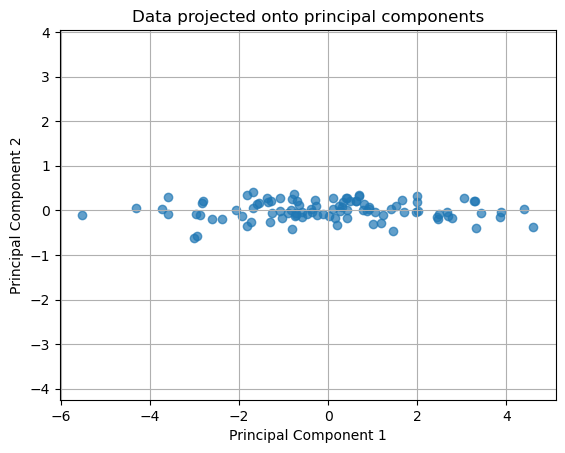

Explained variance ratios: [0.98901026 0.01098974]


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.title('Data projected onto principal components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.axis('equal')
plt.show()

print("Explained variance ratios:", pca.explained_variance_ratio_)